In [11]:
# import packages
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.nn as nn

In [2]:
# verify PyTorch installation
print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

PyTorch Version: 2.11.0+cpu
CUDA Available: False


In [3]:
# define transformations
transform = transforms.ToTensor()

In [4]:
# load MNIST train dataset
train_dataset = datasets.MNIST(
    root="../data",
    train=True,
    download=True,
    transform=transform
)

# load MNIST test dataset
test_dataset = datasets.MNIST(
    root="../data",
    train=False,
    download=True,
    transform=transform
)

In [9]:
# create dataLoaders (batches)
batch_size = 64

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

Training batches: 938
Testing batches: 157


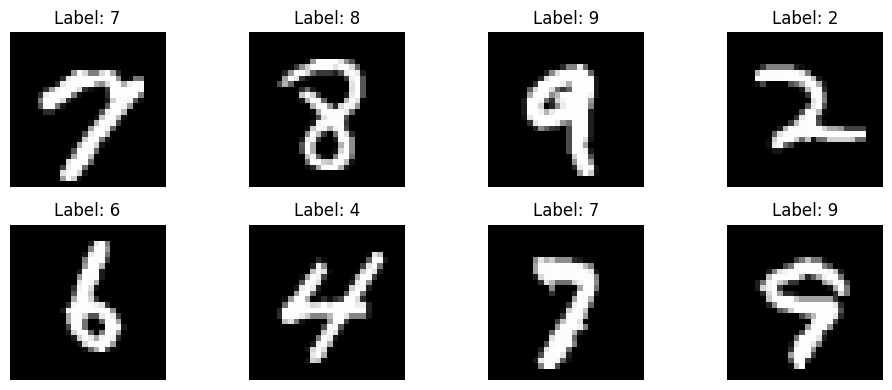

In [10]:
# visualize sample digits
images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 4))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# build neural network
class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10)
        )
        
def forward(self, x):
    return self.model(x)

model = MNISTClassifier()
print(model)

MNISTClassifier(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [13]:
# define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# set same device for model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Using device:", device)

Using device: cpu
